In [59]:
# Pakistan Gold Price Regression Analysis
# ========================================
# Dataset: Pakistan Gold Daily Regression Dataset
# Period: January 2025 - September 2026
#
# Objective:
# Analyze historical 24K gold prices and develop regression
# models to understand and predict gold prices.

In [ ]:
import numpy as np
import pandas as pd

%pip install -q matplotlib

import matplotlib.pyplot as plt
%pip install -q seaborn

import seaborn as sns

%pip install -q --upgrade scikit-learn

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [61]:
file_path = r"C:\Users\arft\Downloads\Pakistan_Gold_Daily_Regression_2025_to_2026-09-01 (1).xlsx"

gold = pd.read_excel(
    file_path,
    sheet_name="Daily_Regression"
)

gold.head()

,Date,Day_of_Week,Day_of_Week_Num,24K_PKR_per_Tola,24K_Daily_Change_PKR,24K_Daily_Change_Pct,Is_Observed,Fill_Basis_Date
0,2025-01-01,Wednesday,3,292000,0,0.0000,1,2025-01-01
1,2025-01-02,Thursday,4,290000,-2000,-0.0068,1,2025-01-02
2,2025-01-03,Friday,5,290500,500,0.0017,1,2025-01-03
3,2025-01-04,Saturday,6,290500,0,0.0000,1,2025-01-04
4,2025-01-05,Sunday,7,290500,0,0.0000,0,2025-01-04


In [62]:
print("Dataset Shape:", gold.shape)

print("\nColumn Names:")
print(gold.columns.tolist())

print("\nData Types:")
print(gold.dtypes)

Dataset Shape: (609, 8)

Column Names:
['Date', 'Day_of_Week', 'Day_of_Week_Num', '24K_PKR_per_Tola', '24K_Daily_Change_PKR', '24K_Daily_Change_Pct', 'Is_Observed', 'Fill_Basis_Date']

Data Types:
Date                    datetime64[ns]
Day_of_Week                     object
Day_of_Week_Num                  int64
24K_PKR_per_Tola                 int64
24K_Daily_Change_PKR             int64
24K_Daily_Change_Pct           float64
Is_Observed                      int64
Fill_Basis_Date         datetime64[ns]
dtype: object


In [63]:
gold.head(10)

,Date,Day_of_Week,Day_of_Week_Num,24K_PKR_per_Tola,24K_Daily_Change_PKR,24K_Daily_Change_Pct,Is_Observed,Fill_Basis_Date
0,2025-01-01,Wednesday,3,292000,0,0.0000,1,2025-01-01
1,2025-01-02,Thursday,4,290000,-2000,-0.0068,1,2025-01-02
2,2025-01-03,Friday,5,290500,500,0.0017,1,2025-01-03
3,2025-01-04,Saturday,6,290500,0,0.0000,1,2025-01-04
4,2025-01-05,Sunday,7,290500,0,0.0000,0,2025-01-04
5,2025-01-06,Monday,1,291000,500,0.0017,1,2025-01-06
6,2025-01-07,Tuesday,2,291500,500,0.0017,1,2025-01-07
7,2025-01-08,Wednesday,3,291500,0,0.0000,1,2025-01-08
8,2025-01-09,Thursday,4,291500,0,0.0000,1,2025-01-09
9,2025-01-10,Friday,5,291000,-500,-0.0017,1,2025-01-10


In [64]:
gold.tail(10)

,Date,Day_of_Week,Day_of_Week_Num,24K_PKR_per_Tola,24K_Daily_Change_PKR,24K_Daily_Change_Pct,Is_Observed,Fill_Basis_Date
599,2026-08-23,Sunday,7,481500,0,0.0000,1,2026-08-23
600,2026-08-24,Monday,1,484000,2500,0.0052,1,2026-08-24
601,2026-08-25,Tuesday,2,484000,0,0.0000,1,2026-08-25
602,2026-08-26,Wednesday,3,484000,0,0.0000,1,2026-08-26
603,2026-08-27,Thursday,4,478000,-6000,-0.0124,1,2026-08-27
604,2026-08-28,Friday,5,477700,-300,-0.0006,1,2026-08-28
605,2026-08-29,Saturday,6,465000,-12700,-0.0266,1,2026-08-29
606,2026-08-30,Sunday,7,465000,0,0.0000,1,2026-08-30
607,2026-08-31,Monday,1,455500,-9500,-0.0204,1,2026-08-31
608,2026-09-01,Tuesday,2,450000,-5500,-0.0121,1,2026-09-01


In [65]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  609 non-null    datetime64[ns]
 1   Day_of_Week           609 non-null    object        
 2   Day_of_Week_Num       609 non-null    int64         
 3   24K_PKR_per_Tola      609 non-null    int64         
 4   24K_Daily_Change_PKR  609 non-null    int64         
 5   24K_Daily_Change_Pct  609 non-null    float64       
 6   Is_Observed           609 non-null    int64         
 7   Fill_Basis_Date       609 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(4), object(1)
memory usage: 38.2+ KB


In [66]:
missing = gold.isnull().sum()

missing_percentage = (
    gold.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing_Values": missing,
    "Missing_Percentage": missing_percentage
})

missing_summary

,Missing_Values,Missing_Percentage
Date,0,0.0000
Day_of_Week,0,0.0000
Day_of_Week_Num,0,0.0000
24K_PKR_per_Tola,0,0.0000
24K_Daily_Change_PKR,0,0.0000
24K_Daily_Change_Pct,0,0.0000
Is_Observed,0,0.0000
Fill_Basis_Date,0,0.0000


In [67]:
duplicate_count = gold.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [68]:
gold["Date"] = pd.to_datetime(gold["Date"])

gold = gold.sort_values("Date").reset_index(drop=True)

print("Date range:")
print(gold["Date"].min(), "to", gold["Date"].max())

Date range:
2025-01-01 00:00:00 to 2026-09-01 00:00:00


In [69]:
gold.describe()

,Date,Day_of_Week_Num,24K_PKR_per_Tola,24K_Daily_Change_PKR,24K_Daily_Change_Pct,Is_Observed,Fill_Basis_Date
count,609,609.0000,609.0000,609.0000,609.0000,609.0000,609
mean,2025-11-01 00:00:00,4.0000,"387,361.1264",259.4417,0.0007,0.8785,2025-10-31 21:05:01.477832448
min,2025-01-01 00:00:00,1.0000,"290,000.0000","-18,000.0000",-0.0398,0.0000,2025-01-01 00:00:00
25%,2025-06-02 00:00:00,2.0000,"348,500.0000",0.0000,0.0000,1.0000,2025-06-02 00:00:00
50%,2025-11-01 00:00:00,4.0000,"402,500.0000",0.0000,0.0000,1.0000,2025-11-01 00:00:00
75%,2026-04-02 00:00:00,6.0000,"428,300.0000",500.0000,0.0015,1.0000,2026-04-02 00:00:00
max,2026-09-01 00:00:00,7.0000,"484,000.0000","35,000.0000",0.0814,1.0000,2026-09-01 00:00:00
std,NaN,2.0016,"49,239.9094","3,051.8824",0.0077,0.3270,NaN


In [70]:
gold.describe(include="all")

,Date,Day_of_Week,Day_of_Week_Num,24K_PKR_per_Tola,24K_Daily_Change_PKR,24K_Daily_Change_Pct,Is_Observed,Fill_Basis_Date
count,609,609,609.0000,609.0000,609.0000,609.0000,609.0000,609
unique,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Wednesday,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,87,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-11-01 00:00:00,NaN,4.0000,"387,361.1264",259.4417,0.0007,0.8785,2025-10-31 21:05:01.477832448
min,2025-01-01 00:00:00,NaN,1.0000,"290,000.0000","-18,000.0000",-0.0398,0.0000,2025-01-01 00:00:00
25%,2025-06-02 00:00:00,NaN,2.0000,"348,500.0000",0.0000,0.0000,1.0000,2025-06-02 00:00:00
50%,2025-11-01 00:00:00,NaN,4.0000,"402,500.0000",0.0000,0.0000,1.0000,2025-11-01 00:00:00
75%,2026-04-02 00:00:00,NaN,6.0000,"428,300.0000",500.0000,0.0015,1.0000,2026-04-02 00:00:00
max,2026-09-01 00:00:00,NaN,7.0000,"484,000.0000","35,000.0000",0.0814,1.0000,2026-09-01 00:00:00


In [71]:
gold.select_dtypes(include=np.number).describe().T

,count,mean,std,min,25%,50%,75%,max
Day_of_Week_Num,609.0000,4.0000,2.0016,1.0000,2.0000,4.0000,6.0000,7.0000
24K_PKR_per_Tola,609.0000,"387,361.1264","49,239.9094","290,000.0000","348,500.0000","402,500.0000","428,300.0000","484,000.0000"
24K_Daily_Change_PKR,609.0000,259.4417,"3,051.8824","-18,000.0000",0.0000,0.0000,500.0000,"35,000.0000"
24K_Daily_Change_Pct,609.0000,0.0007,0.0077,-0.0398,0.0000,0.0000,0.0015,0.0814
Is_Observed,609.0000,0.8785,0.3270,0.0000,1.0000,1.0000,1.0000,1.0000


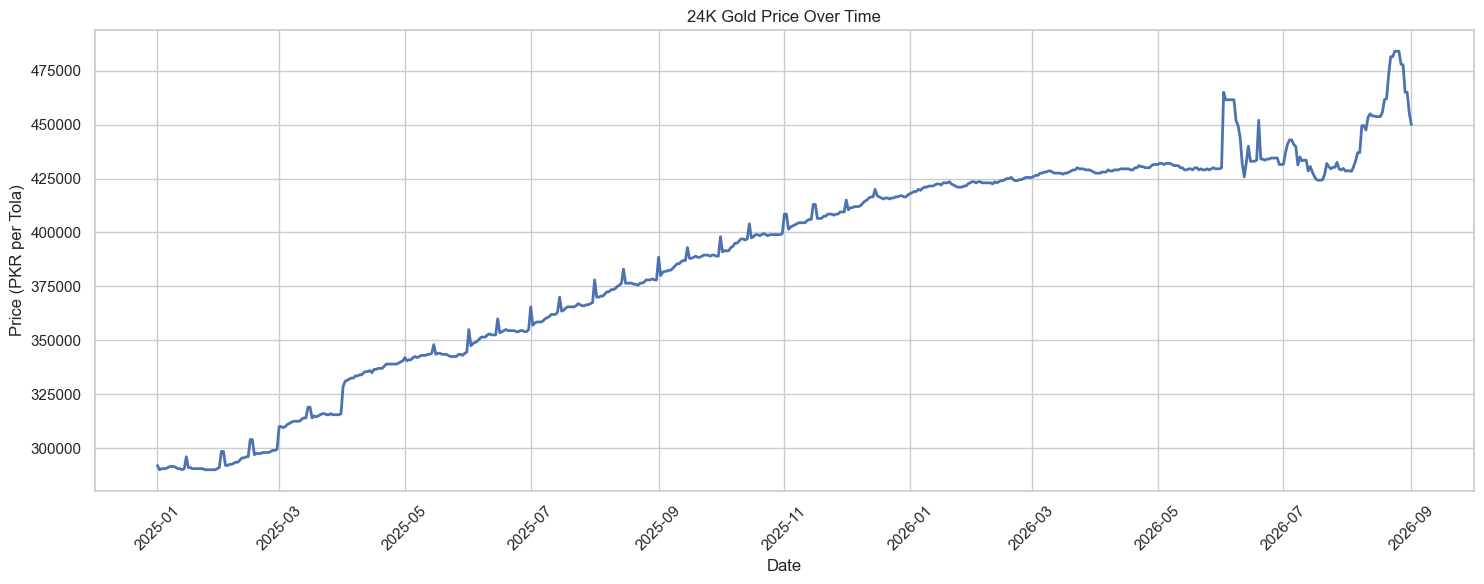

In [72]:
# Gold Price Over Time
plt.figure(figsize=(15, 6))

plt.plot(
    gold["Date"],
    gold["24K_PKR_per_Tola"],
    linewidth=2
)

plt.title("24K Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (PKR per Tola)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

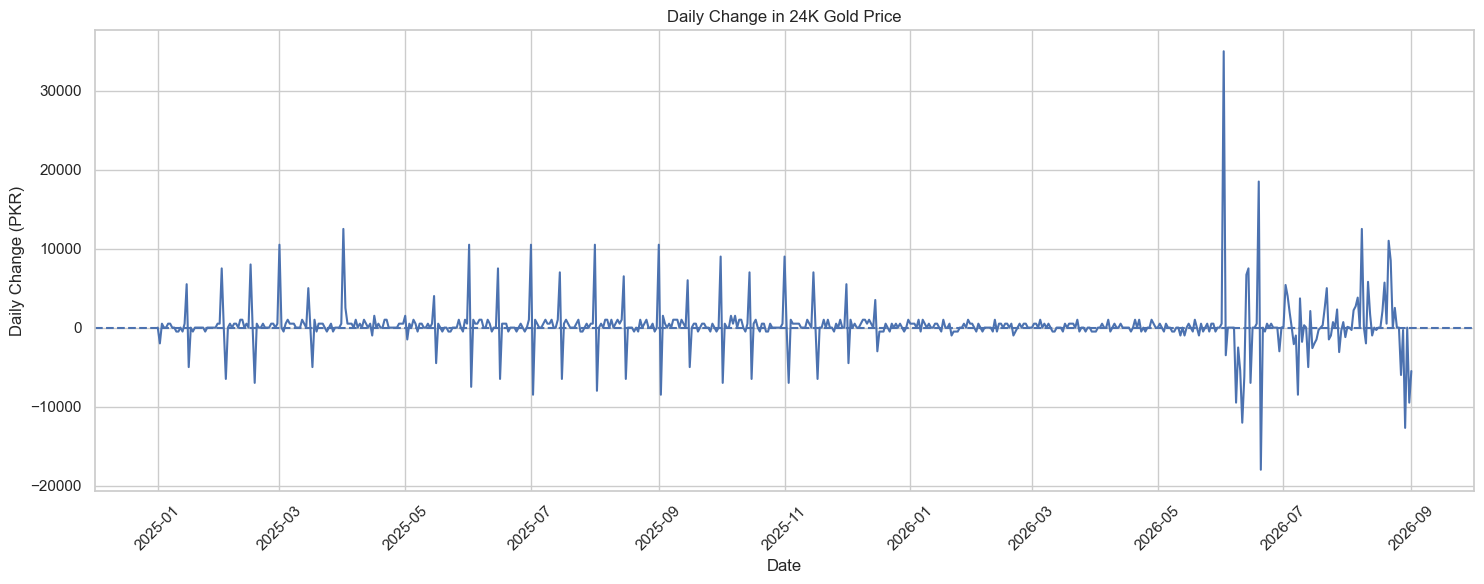

In [73]:
# Daily Change
plt.figure(figsize=(15, 6))

plt.plot(
    gold["Date"],
    gold["24K_Daily_Change_PKR"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Daily Change in 24K Gold Price")
plt.xlabel("Date")
plt.ylabel("Daily Change (PKR)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

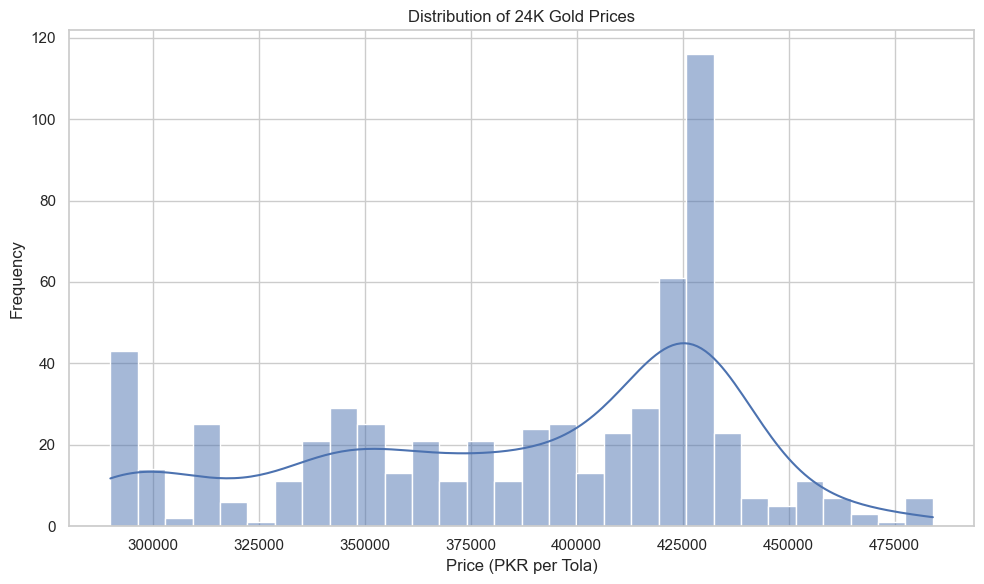

In [74]:
# Distribution of Gold Prices
plt.figure(figsize=(10, 6))

sns.histplot(
    gold["24K_PKR_per_Tola"],
    bins=30,
    kde=True
)

plt.title("Distribution of 24K Gold Prices")
plt.xlabel("Price (PKR per Tola)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

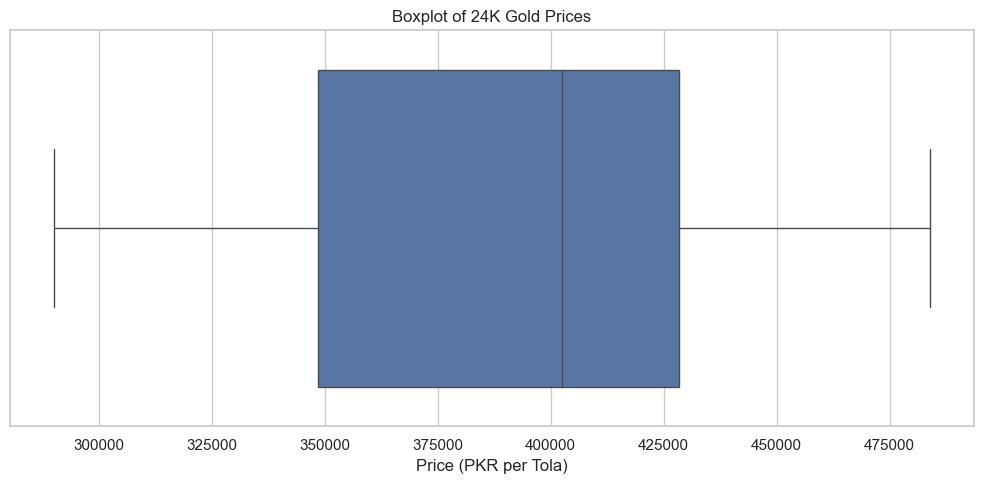

In [75]:
# Outlier Analysis
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=gold["24K_PKR_per_Tola"]
)

plt.title("Boxplot of 24K Gold Prices")
plt.xlabel("Price (PKR per Tola)")

plt.tight_layout()
plt.show()

In [76]:
# Day-of-Week Analysis
day_summary = (
    gold.groupby("Day_of_Week")["24K_PKR_per_Tola"]
    .agg(["mean", "min", "max", "std"])
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

day_summary

,mean,min,max,std
Day_of_Week,,,,
Monday,"387,445.9770",290000,484000,"49,225.0074"
Tuesday,"388,217.0575",290000,484000,"49,300.6702"
Wednesday,"386,685.5402",290000,484000,"49,745.2845"
Thursday,"386,565.5172",290000,478000,"49,590.8980"
Friday,"387,088.5057",290000,477700,"49,891.4739"
Saturday,"387,616.0920",290000,481500,"49,338.0976"
Sunday,"387,909.1954",290000,481500,"49,273.9934"


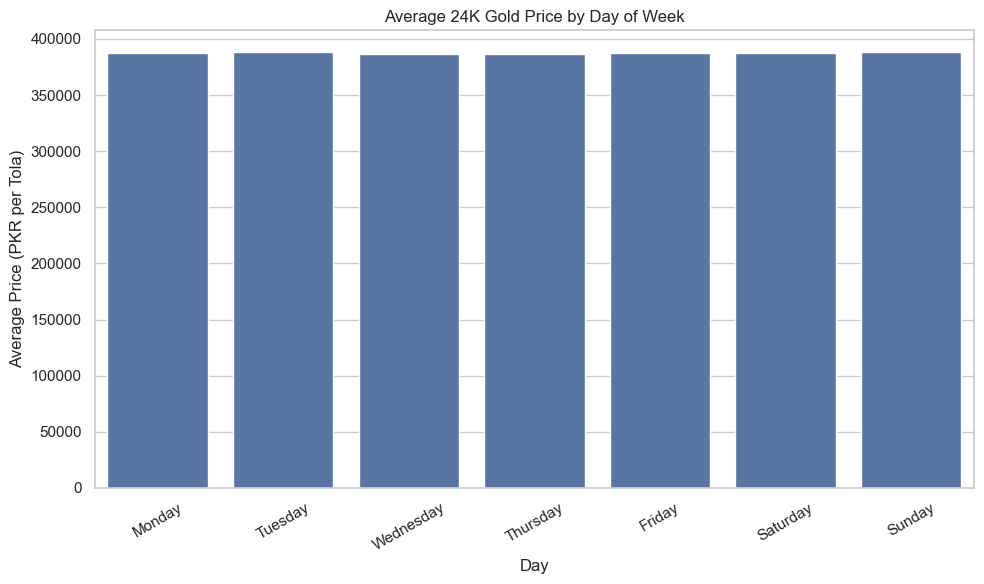

In [77]:
# Visualize it:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=day_summary.index,
    y=day_summary["mean"]
)

plt.title("Average 24K Gold Price by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Price (PKR per Tola)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [78]:
# Observed vs Forward-Filled Data
gold["Is_Observed"].value_counts()

Is_Observed
1    535
0     74
Name: count, dtype: int64

In [79]:
# Percentage of Is-Observed
gold["Is_Observed"].value_counts(normalize=True).mul(100).round(2)

Is_Observed
1   87.8500
0   12.1500
Name: proportion, dtype: float64

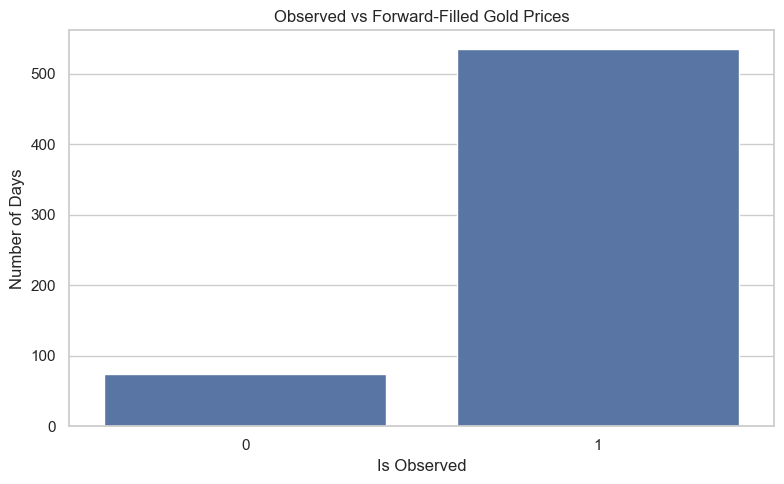

In [80]:
# Visualization of Is-Observed:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=gold,
    x="Is_Observed"
)

plt.title("Observed vs Forward-Filled Gold Prices")
plt.xlabel("Is Observed")
plt.ylabel("Number of Days")

plt.tight_layout()
plt.show()

In [81]:
print("Observed days:",
      (gold["Is_Observed"] == 1).sum())

print("Forward-filled days:",
      (gold["Is_Observed"] == 0).sum())

Observed days: 535
Forward-filled days: 74


In [82]:
# Gold Feature Engineering

# Instead of feeding Date directly into a model, create useful temporal features.
gold["Year"] = gold["Date"].dt.year
gold["Month"] = gold["Date"].dt.month
gold["Day"] = gold["Date"].dt.day
gold["DayOfYear"] = gold["Date"].dt.dayofyear
gold["WeekOfYear"] = gold["Date"].dt.isocalendar().week.astype(int)

gold.head()

,Date,Day_of_Week,Day_of_Week_Num,24K_PKR_per_Tola,24K_Daily_Change_PKR,24K_Daily_Change_Pct,Is_Observed,Fill_Basis_Date,Year,Month,Day,DayOfYear,WeekOfYear
0,2025-01-01,Wednesday,3,292000,0,0.0000,1,2025-01-01,2025,1,1,1,1
1,2025-01-02,Thursday,4,290000,-2000,-0.0068,1,2025-01-02,2025,1,2,2,1
2,2025-01-03,Friday,5,290500,500,0.0017,1,2025-01-03,2025,1,3,3,1
3,2025-01-04,Saturday,6,290500,0,0.0000,1,2025-01-04,2025,1,4,4,1
4,2025-01-05,Sunday,7,290500,0,0.0000,0,2025-01-04,2025,1,5,5,1


In [83]:
#Very Important: Avoid Data Leakage

# For predicting today's gold price, we must not use information that would only be known after today's price is determined.
# Lag Features
gold["Price_Lag_1"] = gold["24K_PKR_per_Tola"].shift(1)
gold["Price_Lag_2"] = gold["24K_PKR_per_Tola"].shift(2)
gold["Price_Lag_7"] = gold["24K_PKR_per_Tola"].shift(7)

gold["Change_Lag_1"] = gold["24K_Daily_Change_PKR"].shift(1)
gold["Change_Lag_7"] = gold["24K_Daily_Change_PKR"].shift(7)

gold.head(10)

,Date,Day_of_Week,Day_of_Week_Num,24K_PKR_per_Tola,24K_Daily_Change_PKR,24K_Daily_Change_Pct,Is_Observed,Fill_Basis_Date,Year,Month,Day,DayOfYear,WeekOfYear,Price_Lag_1,Price_Lag_2,Price_Lag_7,Change_Lag_1,Change_Lag_7
0,2025-01-01,Wednesday,3,292000,0,0.0000,1,2025-01-01,2025,1,1,1,1,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,Thursday,4,290000,-2000,-0.0068,1,2025-01-02,2025,1,2,2,1,"292,000.0000",NaN,NaN,0.0000,NaN
2,2025-01-03,Friday,5,290500,500,0.0017,1,2025-01-03,2025,1,3,3,1,"290,000.0000","292,000.0000",NaN,"-2,000.0000",NaN
3,2025-01-04,Saturday,6,290500,0,0.0000,1,2025-01-04,2025,1,4,4,1,"290,500.0000","290,000.0000",NaN,500.0000,NaN
4,2025-01-05,Sunday,7,290500,0,0.0000,0,2025-01-04,2025,1,5,5,1,"290,500.0000","290,500.0000",NaN,0.0000,NaN
5,2025-01-06,Monday,1,291000,500,0.0017,1,2025-01-06,2025,1,6,6,2,"290,500.0000","290,500.0000",NaN,0.0000,NaN
6,2025-01-07,Tuesday,2,291500,500,0.0017,1,2025-01-07,2025,1,7,7,2,"291,000.0000","290,500.0000",NaN,500.0000,NaN
7,2025-01-08,Wednesday,3,291500,0,0.0000,1,2025-01-08,2025,1,8,8,2,"291,500.0000","291,000.0000","292,000.0000",500.0000,0.0000
8,2025-01-09,Thursday,4,291500,0,0.0000,1,2025-01-09,2025,1,9,9,2,"291,500.0000","291,500.0000","290,000.0000",0.0000,"-2,000.0000"
9,2025-01-10,Friday,5,291000,-500,-0.0017,1,2025-01-10,2025,1,10,10,2,"291,500.0000","291,500.0000","290,500.0000",0.0000,500.0000


In [84]:
# removing lags where values do not exist
gold_model = gold.dropna().copy()

print("Original rows:", len(gold))
print("Rows available for modeling:", len(gold_model))

Original rows: 609
Rows available for modeling: 602


In [85]:
# define Target

target = "24K_PKR_per_Tola"

features = [
    "Day_of_Week_Num",
    "Year",
    "Month",
    "DayOfYear",
    "WeekOfYear",
    "Price_Lag_1",
    "Price_Lag_2",
    "Price_Lag_7",
    "Change_Lag_1",
    "Change_Lag_7"
]

X = gold_model[features]
y = gold_model[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:", target)

Features:
['Day_of_Week_Num', 'Year', 'Month', 'DayOfYear', 'WeekOfYear', 'Price_Lag_1', 'Price_Lag_2', 'Price_Lag_7', 'Change_Lag_1', 'Change_Lag_7']

Target: 24K_PKR_per_Tola


In [86]:
# Time-Based Train/Test Split
split_index = int(len(gold_model) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(
    gold_model.iloc[:split_index]["Date"].min(),
    "to",
    gold_model.iloc[:split_index]["Date"].max()
)

print("\nTesting period:")
print(
    gold_model.iloc[split_index:]["Date"].min(),
    "to",
    gold_model.iloc[split_index:]["Date"].max()
)

Training samples: 481
Testing samples: 121

Training period:
2025-01-08 00:00:00 to 2026-05-03 00:00:00

Testing period:
2026-05-04 00:00:00 to 2026-09-01 00:00:00


In [87]:
# Models
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [88]:
# Train and Evaluate
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
1,Ridge Regression,"3,828.6154","6,203.2126",0.8358
0,Linear Regression,"3,893.9211","6,207.5480",0.8356
2,Random Forest,"10,821.3719","18,274.0323",-0.4248
3,Gradient Boosting,"10,765.8455","18,419.9189",-0.4476


In [89]:
# Actual vs Predicted
best_model = models["Ridge Regression"]

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

In [90]:
comparison = pd.DataFrame({
    "Date": gold_model.iloc[split_index:]["Date"].values,
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(20)

,Date,Actual,Predicted
0,2026-05-04,431500,"432,778.9216"
1,2026-05-05,432000,"432,611.4606"
2,2026-05-06,432000,"432,947.2549"
3,2026-05-07,432000,"433,099.9698"
4,2026-05-08,431500,"433,100.6321"
5,2026-05-09,431000,"432,876.3363"
6,2026-05-10,431000,"432,542.1915"
7,2026-05-11,431000,"431,948.0782"
8,2026-05-12,430000,"431,956.0560"
9,2026-05-13,430000,"431,442.6521"


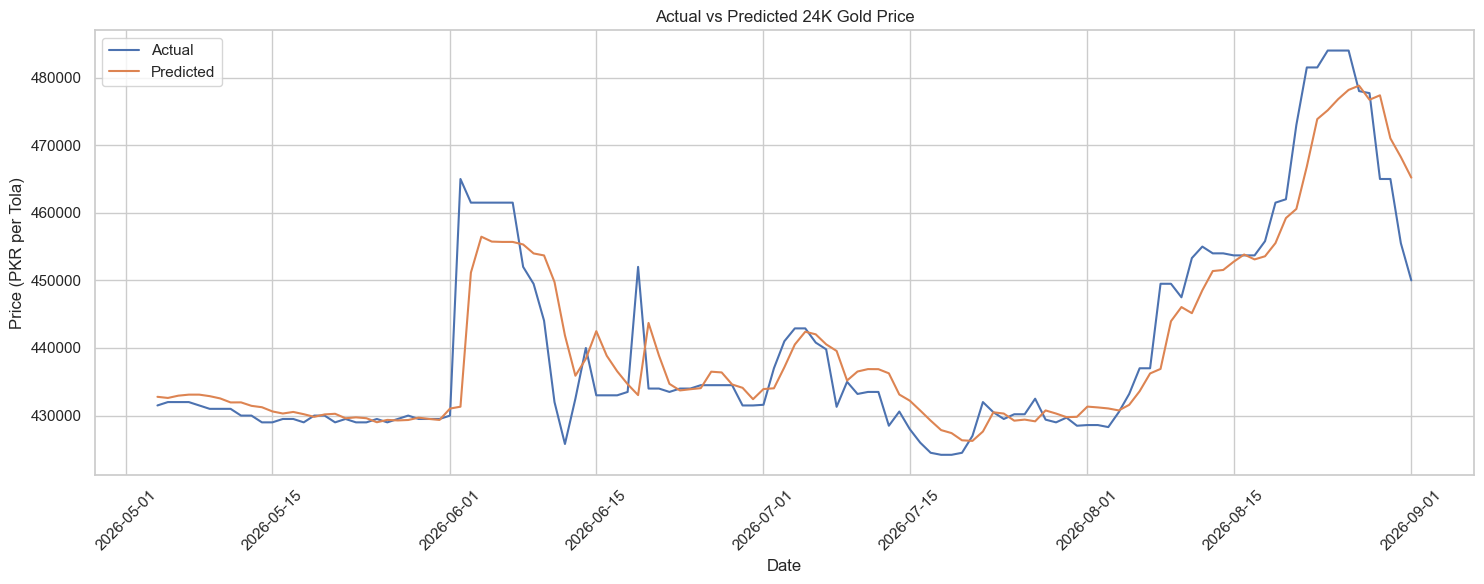

In [91]:
# Graph
plt.figure(figsize=(15, 6))

plt.plot(
    comparison["Date"],
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Date"],
    comparison["Predicted"],
    label="Predicted"
)

plt.title("Actual vs Predicted 24K Gold Price")
plt.xlabel("Date")
plt.ylabel("Price (PKR per Tola)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [92]:
baseline_predictions = X_test["Price_Lag_1"]

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_predictions)
)
baseline_r2 = r2_score(
    y_test, baseline_predictions
)

print("Previous-Day Baseline")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²:", baseline_r2)

Previous-Day Baseline
MAE: 2525.619834710744
RMSE: 5299.224474680975
R²: 0.8801848489082018


In [93]:
gold["Is_Observed"].value_counts()

Is_Observed
1    535
0     74
Name: count, dtype: int64